<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_2_3_%D0%94%D0%B5%D1%80%D0%B5%D0%B2%D0%B0_%D0%BF%D1%80%D0%B8%D0%B9%D0%BD%D1%8F%D1%82%D1%82%D1%8F_%D1%80%D1%96%D1%88%D0%B5%D0%BD%D1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



In [1]:
#install of necessary modules
!pip install opendatasets --upgrade --quiet

In [2]:
#import of modules
import opendatasets as od
import pandas as pd
from process_bank_churn import preprocess_data
from process_bank_churn import preprocess_new_data
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
import seaborn as sns

In [3]:
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-4/data'

In [4]:
od.download(dataset_url)

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-4" (use force=True to force download)


In [5]:
raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/train.csv')

In [6]:
data = preprocess_data(raw_df, scaler_numeric = False)

#Посилання на файл з prepocessing
https://github.com/fox-n/ML_course_homeworks/blob/main/process_bank_churn.py

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [7]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']


In [8]:
model = DecisionTreeClassifier(random_state=42)

In [9]:
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [10]:
train_preds = model.predict(X_train)

In [11]:
model.score(X_train, train_targets)

1.0

In [12]:
model.score(X_val, val_targets)

0.8373333333333334

In [13]:
model.tree_.max_depth

26

In [14]:
#ROC curve
def compute_auroc_and_build_roc(inputs, targets, model, build_graph = True, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba, pos_label=1)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)


  if build_graph:
    print(f'AUROC for {name}: {roc_auc:.2f}')
    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show()
  else:
    return roc_auc

AUROC for Training: 1.00


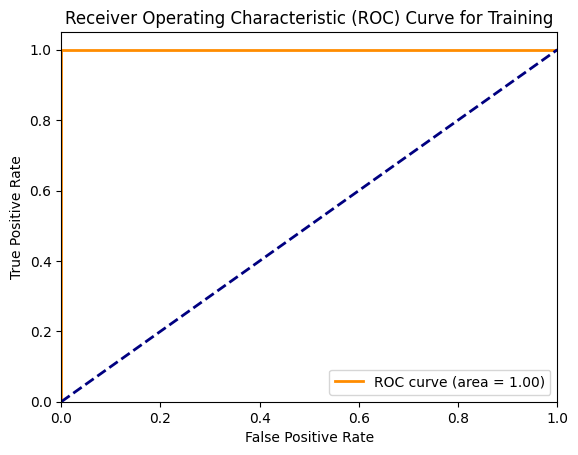

AUROC for Validation: 0.77


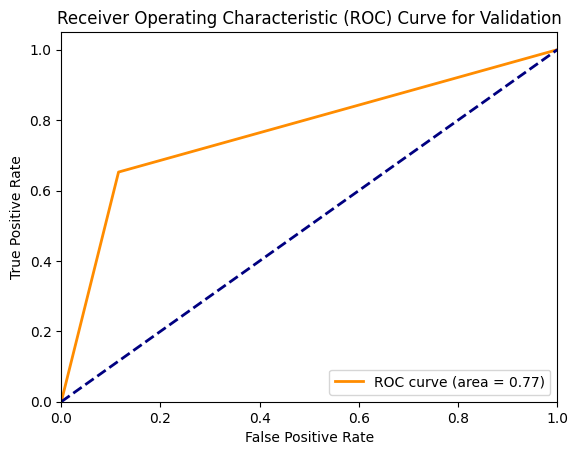

In [15]:
compute_auroc_and_build_roc(X_train, train_targets, model,True, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, model,True, 'Validation')


In [16]:
val_targets.value_counts() / len(val_targets)

,count
Exited,
0.0,0.796667
1.0,0.203333


#Проміжний висновок
Модель перенавчена, адже на тренувальному датасеті вона показала Auroc = 1, а на валідаційному - 0.77 - це велика різниця. Якщо порівняти з моделю, яка передбачає постійно 0, то моя модель виходить гірша за точністю.
Дерево побудувалось глибиною 26.

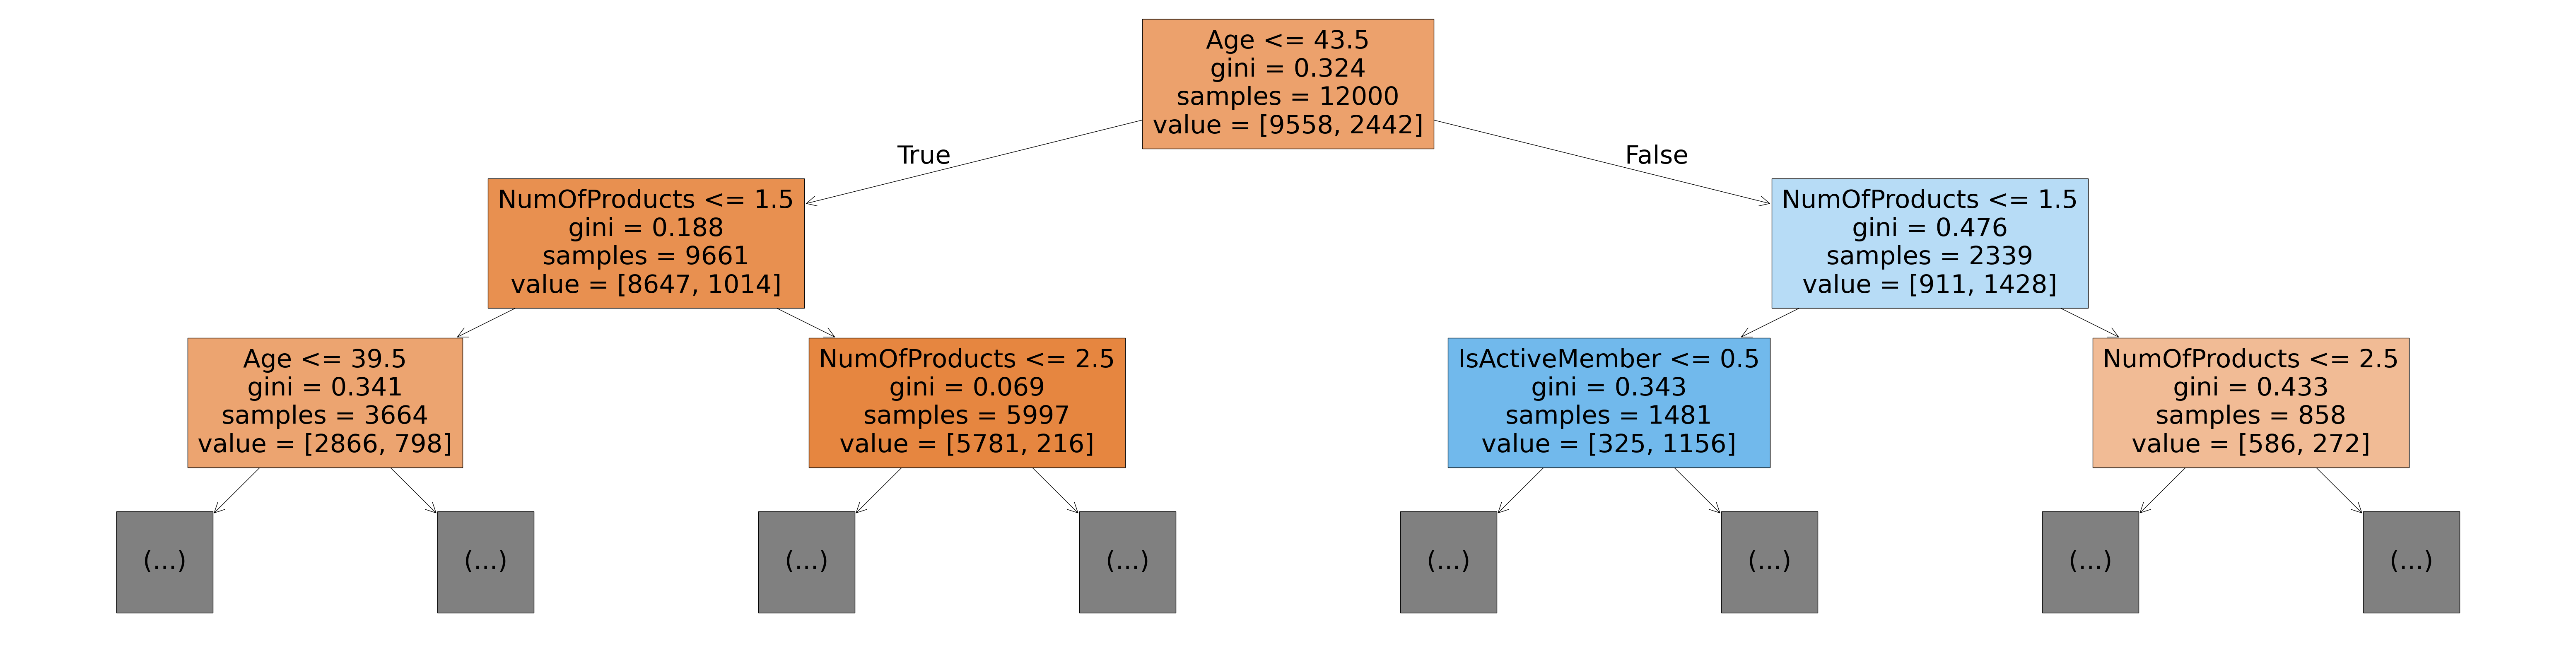

In [17]:
#Tree visualization

plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

In [18]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- Age <= 39.50
|   |   |   |--- truncated branch of depth 24
|   |   |--- Age >  39.50
|   |   |   |--- truncated branch of depth 19
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- truncated branch of depth 20
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- truncated branch of depth 7
|--- Age >  43.50
|   |--- NumOfProducts <= 1.50
|   |   |--- IsActiveMember <= 0.50
|   |   |   |--- truncated branch of depth 15
|   |   |--- IsActiveMember >  0.50
|   |   |   |--- truncated branch of depth 15
|   |--- NumOfProducts >  1.50
|   |   |--- NumOfProducts <= 2.50
|   |   |   |--- truncated branch of depth 17
|   |   |--- NumOfProducts >  2.50
|   |   |   |--- class: 1.0



#Проміжний висновок:
Найвливовішими ознаками є Age, NumOfProducts, IsActiveMember

In [19]:
#Побудова розподілу важливості ознак
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [20]:
importance_df.head(10)

,feature,importance
2,Age,0.327757
5,NumOfProducts,0.168379
8,EstimatedSalary,0.121012
0,CreditScore,0.111801
10,Age_Balance,0.052321
4,Balance,0.045920
3,Tenure,0.040930
9,Age_IsActive,0.027488
11,Gender_Age,0.025780
7,IsActiveMember,0.017275


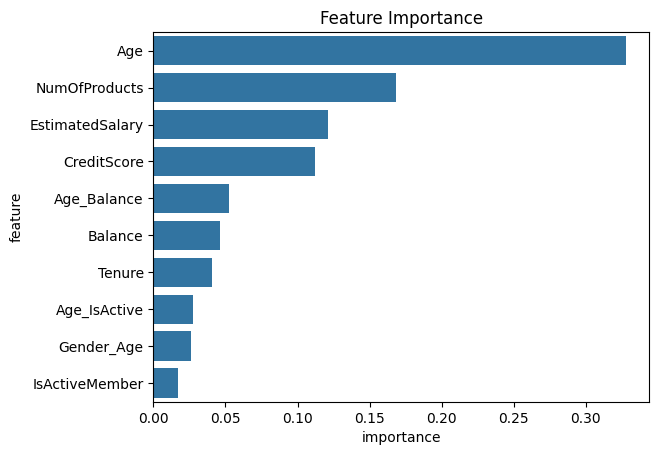

In [21]:
plt.title('Feature Importance')
sns.barplot(data=importance_df.head(10), x='importance', y='feature');

#Висновок
Модель перенавчена, а найбільш впливовими ознаками є Age, NumOfProducts, EstimatedSalary, CreditScore, etc

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [22]:
def params_experiments(max_depth = None, max_leaf_nodes = None):
  params = {}
  if max_depth is not None:
      params['max_depth'] = max_depth
  if max_leaf_nodes is not None:
      params['max_leaf_nodes'] = max_leaf_nodes
  Local_model = DecisionTreeClassifier(**params, random_state=42)

  Local_model.fit(X_train, train_targets)

  train_rocauc = compute_auroc_and_build_roc(X_train, train_targets, Local_model, False, 'Training')
  val_rocauc = compute_auroc_and_build_roc(X_val, val_targets, Local_model, False, 'Validation')

  return train_rocauc, val_rocauc

In [23]:
train_rocauc, val_rocauc = params_experiments(2)
print(f'train_rocauc: {train_rocauc.round(3)}, val_rocauc: {val_rocauc.round(3)}')


train_rocauc: 0.843, val_rocauc: 0.846


In [24]:
params_experiments(5)


(np.float64(0.924748130256605), np.float64(0.9190393716990193))

In [25]:
params_experiments(None, 100)

(np.float64(0.9369186212406552), np.float64(0.9066348857946361))

In [26]:
params_experiments(None, 50)

(np.float64(0.9315806775787944), np.float64(0.9167693257425064))

In [27]:
params_experiments(None, 20)

(np.float64(0.9179236804001399), np.float64(0.9171856780300432))

In [28]:
params_experiments(5,20)

(np.float64(0.9162518322122842), np.float64(0.9159513684066123))

#Висновок
З моїх експериментів виходить, що найбльш оптимальними значеннями, коли точність і стабільність моделі підвищується, max_depth = 5 або max_leaf_nodes = 20, або ці обидва параметри мають такі значення одночасно

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [29]:
def auroc_calc(max_depth, max_leaf_nodes):

  train_rocauc, val_rocauc = params_experiments(max_depth, max_leaf_nodes)

  return {'Max Depth': max_depth, 'Training AUROC': train_rocauc, 'Validation AUROC': val_rocauc}

In [30]:
aurocs_df = pd.DataFrame([auroc_calc(md, None) for md in range(1, 21)])

In [31]:
aurocs_df.style.background_gradient(subset='Validation AUROC', cmap='Blues_r')

,Max Depth,Training AUROC,Validation AUROC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911532,0.911003
4,5,0.924748,0.919039
5,6,0.933773,0.916801
6,7,0.940770,0.913397
7,8,0.949523,0.897151
8,9,0.959910,0.867392
9,10,0.970087,0.849204


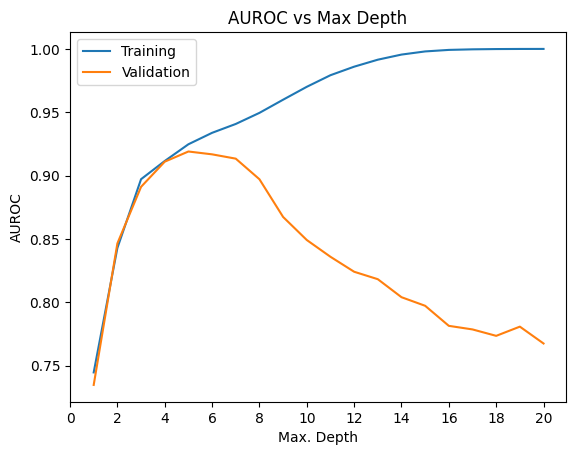

In [32]:
plt.figure()
plt.plot(aurocs_df['Max Depth'], aurocs_df['Training AUROC'])
plt.plot(aurocs_df['Max Depth'], aurocs_df['Validation AUROC'])
plt.title('AUROC vs Max Depth')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

#Висновок
На графіку AUROC vs Max Depth видно, що зі зростанням max depth, модель починає погано генералізувати, адже точність моделі на тренувальних даних зростає, а на валідаційних - падає. Тобто відбувається overfit. Оптимальним значенням є max depth = 5.

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [56]:
#teaching of model with the best parameters

final_model = DecisionTreeClassifier(max_depth = 5, random_state=42)

final_model.fit(X_train, train_targets)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [57]:
test_raw_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/test.csv')

In [58]:
scaler = data['scaler']
encoder = data['encoder']

In [59]:
test_data = preprocess_new_data(test_raw_df, scaler, encoder)

In [60]:
test_data

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Age_IsActive,...,Gender_Age,Geography_France,Geography_Germany,Geography_Spain,Clients loyality_Few_years_aquainted,Clients loyality_Most_loyal,Clients loyality_New_clients,AgeGroup_18-25,AgeGroup_25-55,AgeGroup_older then 55
0,584.0,1,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,30.0,...,30.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,551.0,1,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,39.0,...,39.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,706.0,1,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.0,...,43.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,717.0,1,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,45.0,...,45.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
4,592.0,1,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,43.0,...,43.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,639.0,1,38.0,10.0,0.00,2.0,1.0,1.0,49637.65,38.0,...,38.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9996,678.0,1,39.0,9.0,0.00,2.0,1.0,1.0,142513.50,39.0,...,39.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
9997,774.0,1,30.0,9.0,0.00,2.0,1.0,0.0,4861.72,0.0,...,30.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9998,595.0,1,38.0,6.0,144875.79,1.0,1.0,0.0,126469.09,0.0,...,38.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [61]:
prob = final_model.predict_proba(test_data)[:, 1]

In [62]:
prob.shape

(10000,)

In [63]:
sample_submission_df = pd.read_csv('/content/bank-customer-churn-prediction-dlu-course-c-4/sample_submission.csv')

In [64]:
test_raw_df['Exited'] = prob

sample_submission_df['Exited'] = sample_submission_df['id'].map(
    test_raw_df.set_index('id')['Exited']
)

sample_submission_df.head(5)
sample_submission_df.to_csv('submission_trees.csv', index=False)

In [65]:
sample_submission_df.head(5)

,id,Exited
0,15000,0.237911
1,15001,0.011859
2,15002,0.047198
3,15003,0.770925
4,15004,0.047198
